In [ ]:
import pandas as pd
import scipy as sp
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.graphics.factorplots import interaction_plot
from statsmodels.graphics.gofplots import qqplot
import seaborn as sb

Ще разгледаме данни за броя на реклами от различни теми във вестник през дните от седмицата.

## Задача 1
Заредете данните от файла "newspaper_ads.xls" в "data" папката. Поправете правописната грешка в стойността за четвъртък.

In [ ]:
df = pd.read_excel('data/newspaper_ads.xls')
df

,Day,News,Business,Sports
0,Monday,11,10,4
1,NaN,8,12,3
2,NaN,6,13,5
3,NaN,8,11,6
4,Tuesday,9,7,5
5,NaN,10,8,8
6,NaN,10,11,6
7,NaN,12,9,7
8,Wednesday,8,7,5
9,NaN,9,8,9


In [ ]:
df.iloc[12, 0] = 'Thursday'

## Задача 2
Трансформирайте данните в подходящ формат за ANOVA.
- В колоната "Day" трябва да имаме деня на всеки ред
- Тряабва на всеки ред да имаме по 1 наблюдение, т.е. колоните News 	Business и Sports трябва да станат стойности в една колона 

В колоната "Day" трябва да имаме деня на всеки ред, т.е. трябва да попълним NaN. Това става с fillna функцията с аргумент method='ffill'. Това е съкращение на forward fill. Означава, че минаваме през колоната и заместваме NaN стойностите с последната стойност, която не е NaN.

In [ ]:
df['Day'] = df['Day'].fillna(method='ffill')
df

TypeError: NDFrame.fillna() got an unexpected keyword argument 'method'

Искаме данните да са във такъв формат, че да имаме по едно наблюдение на ред. В момента имаме по 3 на ред - по 1 за всеки тип. За целта трябва да "разтопим" таблицата като използваме фунцкията [melt](https://pandas.pydata.org/pandas-docs/version/0.23.4/generated/pandas.melt.html). Функцията melt приема 3 аргумента:

    -id_vars: това са колоните, които няма да разтапяме. Те ще си останат като колони след извикването на функцията.
    -value_vars: колоните, които ще разтопим. Тези колони ще станат стойностите на новата колона, която ще се създаде. Ако не подадем стойност за този аргумент, ще се използват всички колони, които не са в id_vars.
    -var_name: името на новата колона.

In [ ]:
df = df.melt(id_vars=['Day'], var_name='Type')
df

,Day,Type,value
0,Monday,News,11
1,Monday,News,8
2,Monday,News,6
3,Monday,News,8
4,Tuesday,News,9
5,Tuesday,News,10
6,Tuesday,News,10
7,Tuesday,News,12
8,Wednesday,News,8
9,Wednesday,News,9


## Задача 3

- Начертайте boxplot на стойностите за различните типове реклами
- Начертайте boxplot на стойностите за различните дни
- Начертайте boxplot на стойностите едновременно за различните типове реклами и различните дни

<AxesSubplot:xlabel='Type', ylabel='value'>

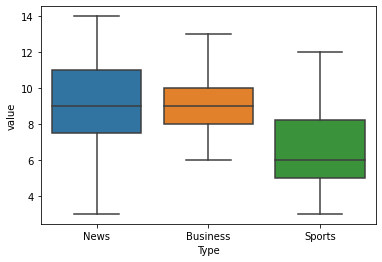

In [ ]:
sb.boxplot(x='Type', y='value', data=df)

<AxesSubplot:xlabel='Day', ylabel='value'>

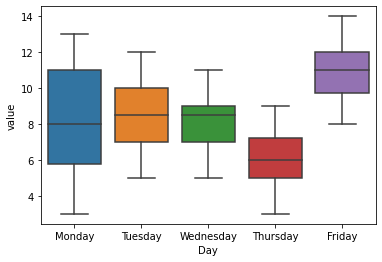

In [ ]:
sb.boxplot(x='Day', y='value', data=df)

Можем да начертаем едновременно деня и типа на данните

<AxesSubplot:xlabel='Day', ylabel='value'>

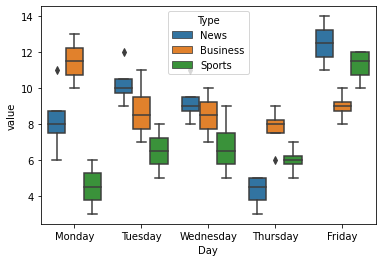

In [ ]:
sb.boxplot(x='Day', y='value',hue='Type', data=df)

Така информацията става малко вповече. По добре се визуализират само средните с interaction plot

## Задача 4 
- Пресметнете средните стойноти на броя реклами за всяка комбинация от предиктори (treatment)
- Начертайте interaction plot на данните

In [ ]:
df.groupby(['Day', 'Type']).mean()

value
Day       Type           
Friday    Business   9.00
          News      12.50
          Sports    11.25
Monday    Business  11.50
          News       8.25
          Sports     4.50
Thursday  Business   7.75
          News       4.25
          Sports     6.00
Tuesday   Business   8.75
          News      10.25
          Sports     6.50
Wednesday Business   8.50
          News       9.25
          Sports     6.75

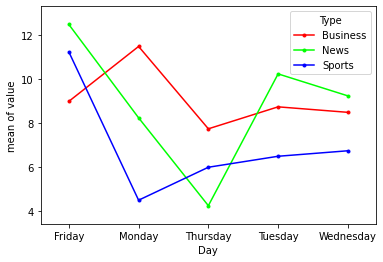

In [ ]:
fig = interaction_plot(df.Day, df.Type, df.value)

## Задача 5
Направете ANOVA върху модел на обикновенни най-малки квадрати. Анализирайте резултатите

In [ ]:
model = ols(formula='value ~ C(Type)*C(Day)', data=df)
result = model.fit()
anova_table = sm.stats.anova_lm(results, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(Type),53.733333,2.0,15.303797,8.502752e-06
C(Day),146.833333,4.0,20.909810,8.517535e-10
C(Type):C(Day),135.766667,8.0,9.666930,1.124687e-07
Residual,79.000000,45.0,NaN,NaN


## Задача 6
Тествайте грешките за нормалност
- начертайте хистограма
- начертайте qqplot
- направете тест на Шапиро-Уилк

<AxesSubplot:>

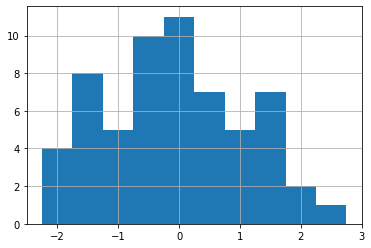

In [ ]:
result.resid.hist()

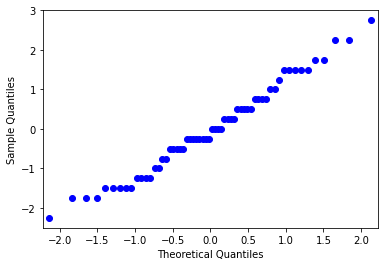

In [ ]:
plot = qqplot(result.resid)

In [ ]:
sp.stats.shapiro(result.resid)

ShapiroResult(statistic=0.9769867062568665, pvalue=0.31468889117240906)